# Notebook 03 — Feature Engineering

**Philippine Weekly Diesel Price Forecasting**

### References

- Lunor, S.B.R. et al. (2023). Machine Learning Approach for Pump Price Prediction for the Philippines Post COVID-19. *Chemical Engineering Transactions*, 103, 265–270.
- Wen, D. et al. (2025). Forecasting gasoline prices: New evidence based on the rocket and feather hypothesis. *Energy*, 335.
- Borenstein, S., Cameron, A.C., & Gilbert, R. (1997). Do Gasoline Prices Respond Asymmetrically to Crude Oil Price Changes? *Quarterly Journal of Economics*, 112(1), 305–339.
- Caldara, D. & Iacoviello, M. (2022). Measuring Geopolitical Risk. *American Economic Review*, 112(4), 1194–1225.
- Hamilton, J.D. (1989). A New Approach to the Economic Analysis of Nonstationary Time Series. *Econometrica*, 57(2), 357–384.

### EDA decisions implemented in this notebook

| # | EDA Finding | Engineering Decision |
|---|---|---|
| 1 | Diesel price is I(1) — non-stationary in levels (ADF p > 0.05) | Model on **log returns** Δlog(diesel), not levels |
| 2 | Lag-0 same-week Brent/FX — temporal data leakage | All market features lagged ≥ 1 week before the DOE Tuesday bulletin |
| 3 | CCF MOPS→diesel peaks at lag 1, decays by lag 4 | Lags 1–4 on upstream drivers |
| 4 | Own-price autocorrelation ≈ 0.97 | Own log-return lags 1–4 unconditionally included |
| 5 | RFH asymmetry confirmed in diesel | Split Brent Δlog into positive / negative components (Wen et al., 2025) |
| 6 | Markov variance ratio ≈ 32× — two clear volatility regimes | `markov_prob_highvol` as a continuous regime covariate |
| 7 | Crisis shocks outside normal regime | Binary dummies: COVID-19, Russia–Ukraine, OPEC+/Iran 2026 |
| 8 | MOPS flagged as leakage | Replaced by `crack_spread` = mops_gasoil − brent (refining margin, correct sign) |
| 9 | Excise tax is structurally embedded in the observed pump price | Excise **fully excluded** — level is in the target by construction; no independent signal |
| 10 | Brent–Dubai r ≈ 0.99; Dubai adds no marginal information after Brent | Dubai dropped; Brent retained as the global benchmark used in the DOE pricing formula |
| 11 | OVX, VIX, Markov prob. form a correlated volatility cluster | Separate **volatility PCA block** (OVX, VIX, Markov high-vol prob.) |
| 12 | GPR sub-indices (GPR_AI, GPR_NONOIL, GPR_OIL_MiddleEast, GPR_OIL_Russia) highly correlated (r up to 0.96) | Separate **GPR PCA block**; GPR_OIL retained as standalone direct feature |
| 13 | CPI monthly, forward-filled; level is non-stationary | `cpi_yoy = cpi_value.pct_change(52)×100` — year-on-year inflation rate (stationary) |

### On the modeling target

The ADF test confirmed all price series are **I(1)**. Modelling price levels is therefore spurious — the
model learns the trend, not the signal, and degenerates to the AR(1) copy: $\hat p_t \approx p_{t-1}$
(the professor's critique). The correct transformation is the **log return**:

$$r_t = \Delta\log p_t = \log\left(\frac{p_t}{p_{t-1}}\right)$$

which is stationary by construction. At prediction time the level is recovered via

$$\hat{p}_t = p_{t-1} \cdot \exp(\hat{r}_t)$$

This notebook engineers all features for the **diesel** product only. The same pipeline extends to
`ron91`, `ron95`, `ron97` with the appropriate own-price lags substituted.


---
## Section 1 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as transforms
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import t as t_dist

# Import professor's utility functions
import sys
sys.path.insert(0, '.')
from utils import plot_cum_exp_var, plot_principal_components

os.makedirs('data/final', exist_ok=True)

# ── Plotting style — clean, no grid, matches professor's notebook ──────────
plt.rcParams.update({
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          False,
    'figure.dpi':         100,
})

# ── Crisis shade bands (for time-series plots) ─────────────────────────────
CRISIS_BANDS = [
    ('2020-03-09', '2020-06-15', '#4e79a7', 'COVID-19'),
    ('2022-02-24', '2022-12-31', '#e15759', 'Russia–Ukraine'),
    ('2026-01-01', '2026-04-30', '#f28e2b', 'OPEC+/Iran 2026'),
]

def shade_crises(ax, alpha=0.12):
    """Shade crisis periods on a time-series axis."""
    for start, end, color, label in CRISIS_BANDS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color=color, alpha=alpha, label=label)

def fmt_xaxis(ax):
    """Format x-axis as 4-digit year labels."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

# ── Constants ─────────────────────────────────────────────────────────────
TARGET_PRODUCT = 'diesel'
LAGS           = [1, 2, 3, 4]


---
## Section 2 — Load Master Frame

We load from `master_pre_engineered.parquet`, the output of Notebook 02. This frame contains all
raw weekly series aligned on the DOE Tuesday bulletin index, along with regime flags computed in
the EDA (Markov state probability, crisis dummies, structural break labels).


In [2]:
df = pd.read_parquet('data/final/master_pre_engineered.parquet')

print(f'Shape  : {df.shape}')
print(f'Dates  : {df.index.min().date()}  →  {df.index.max().date()}')
print(f'Index  : {df.index.name}  ({df.index.dtype})')
print()
print('Columns:')
for c in df.columns:
    print(f'  {c}')


Shape  : (373, 34)
Dates  : 2018-02-13  →  2026-04-28
Index  : None  (datetime64[ns])

Columns:
  usd_php_mean
  brent_mean
  mops_gasoil_mean
  mops_rbob_mean
  dubai_close
  cpi_value
  rub_usd_mean
  vix_mean
  GPR_AI
  GPR_OIL
  GPR_OIL_MiddleEast
  GPR_OIL_Russia
  GPR_NONOIL
  ovx_mean
  diesel
  diesel_plus
  kerosene
  ron100
  ron91
  ron95
  ron97
  diesel_chg
  markov_prob_highvol
  markov_regime_flag
  d_covid
  d_ukraine
  d_iran26
  anomaly_flag
  crisis_intensity
  iso_score
  iso_flag
  pelt_regime
  ovx_z
  gpr_z


### 2.1 Diesel null handling

The DOE occasionally skips a bulletin week (holiday, data delay). Forward-fill is the only
safe strategy: it carries the last observed price forward, which is what a market participant
would also assume. **Back-fill is never used** — it would propagate a future price into a past
row, introducing look-ahead bias.


In [3]:
# Forward-fill diesel only — no bfill
df[TARGET_PRODUCT] = df[TARGET_PRODUCT].ffill()

n_remaining_null = df[TARGET_PRODUCT].isna().sum()
print(f'Null diesel prices after ffill : {n_remaining_null}')
if n_remaining_null > 0:
    print('  → Dropping leading rows with no prior observation.')
    df = df.dropna(subset=[TARGET_PRODUCT])

print(f'Working rows : {len(df)}')
print(f'Date range   : {df.index.min().date()}  →  {df.index.max().date()}')


Null diesel prices after ffill : 0
Working rows : 373
Date range   : 2018-02-13  →  2026-04-28


---
## Section 3 — Modeling Target: Diesel Log Return

The modeling target is the week-on-week log return of the diesel pump price:

$$r_t = \log\left(\frac{p_t}{p_{t-1}}\right)$$

This is the **first log-difference** of the level series. The EDA (Section 4) confirmed via
Augmented Dickey–Fuller that the level series is I(1) and the first-differenced series is
stationary (ADF p < 0.01). Log returns are preferred over raw differences because they are
symmetric, approximately normally distributed, and admit a clean back-transformation to price
levels without compounding errors.

**All models in Notebook 04 predict `diesel_log_ret`. Level predictions are recovered as
$\hat{p}_t = p_{t-1} \cdot \exp(\hat{r}_t)$ before computing MAPE.**


In [4]:
# ── Construct log return ───────────────────────────────────────────────────
df['diesel_log_ret'] = np.log(df[TARGET_PRODUCT] / df[TARGET_PRODUCT].shift(1))

# Descriptive check
desc = df['diesel_log_ret'].describe()
print('Diesel log return — descriptive statistics')
print('-' * 44)
print(desc.round(6).to_string())
print()
print('Interpretation:')
print(f'  Mean  ≈ 0 (weekly average change near zero) : {df["diesel_log_ret"].mean():.5f}')
print(f'  Std   ≈ 0.01–0.05 for administered prices   : {df["diesel_log_ret"].std():.5f}')
print(f'  Range : [{df["diesel_log_ret"].min():.4f},  {df["diesel_log_ret"].max():.4f}]')


Diesel log return — descriptive statistics
--------------------------------------------
count    372.000000
mean       0.002091
std        0.042640
min       -0.224966
25%       -0.014623
50%        0.000476
75%        0.017033
max        0.334706

Interpretation:
  Mean  ≈ 0 (weekly average change near zero) : 0.00209
  Std   ≈ 0.01–0.05 for administered prices   : 0.04264
  Range : [-0.2250,  0.3347]


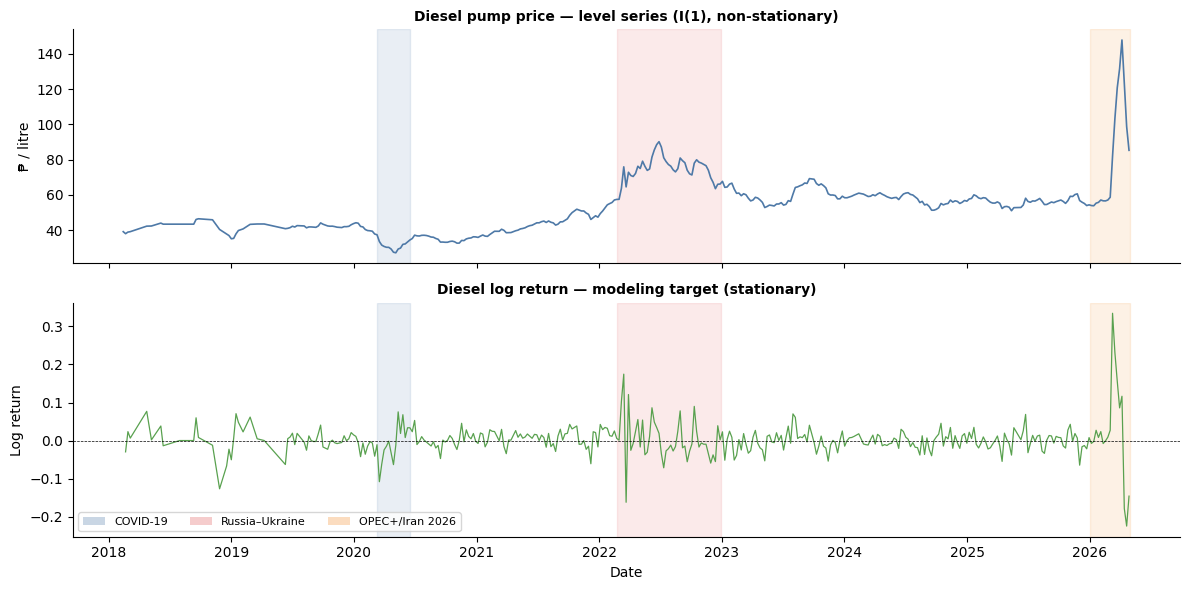

→ Notebook 04 predicts diesel_log_ret.
  Back-transform: price_t = price_{t-1} × exp(log_ret_hat)


In [5]:
# ── Visualise: levels vs log returns ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.subplots_adjust(hspace=0.08)

ax = axes[0]
ax.plot(df.index, df[TARGET_PRODUCT], color='#4e79a7', linewidth=1.2)
shade_crises(ax)
ax.set_ylabel('₱ / litre', fontsize=10)
ax.set_title('Diesel pump price — level series (I(1), non-stationary)',
             fontsize=10, fontweight='bold')

ax = axes[1]
ax.plot(df['diesel_log_ret'].dropna().index,
        df['diesel_log_ret'].dropna(),
        color='#59a14f', linewidth=0.9)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
shade_crises(ax)
ax.set_ylabel('Log return', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.set_title('Diesel log return — modeling target (stationary)', fontsize=10, fontweight='bold')

for ax in axes:
    fmt_xaxis(ax)

# Crisis legend on bottom panel only
handles = [plt.Rectangle((0, 0), 1, 1, fc=c, alpha=0.3)
           for _, _, c, _ in CRISIS_BANDS]
labels  = [lbl for _, _, _, lbl in CRISIS_BANDS]
axes[1].legend(handles, labels, fontsize=8, loc='lower left', ncol=3)

plt.tight_layout()
plt.show()

print('→ Notebook 04 predicts diesel_log_ret.')
print('  Back-transform: price_t = price_{t-1} × exp(log_ret_hat)')


---
## Section 4 — Derived Features

All derived features are computed on the **raw (unlagged) series** at this stage.
The lag shift is applied systematically in Section 5. This separation makes the
construction logic transparent and avoids confusion between the feature value and
its temporal placement relative to the target.

### 4.1 Crack spread (refining margin)

The crack spread is the difference between the price of a refined petroleum product and its
crude oil feedstock. It measures the refining margin — the economic incentive for refiners.
For diesel, the relevant spread is gasoil (distillate) minus crude:

$$\text{crack\_spread}_t = \text{MOPS gasoil}_t - \text{Brent}_t$$

The sign convention is critical: **refined product minus crude**. A positive crack spread
indicates a profitable refining environment; a rising crack spread signals upstream cost
pressure that precedes pump price increases. The earlier notebook had this inverted
(Brent − MOPS), which reverses the economic interpretation.

Note: MOPS is used here only to compute the crack spread as a derived signal, not as a
direct input. The professor's leakage concern applies to using MOPS gasoil as a direct
price proxy for the DOE formula; using it as one component of a spread is defensible
because the spread captures a *margin* not available from crude alone.


In [6]:
# ── 4.1 Crack spread: MOPS gasoil minus Brent ─────────────────────────────
# Sign: refined product − crude = refining margin (positive = profitable)
if 'mops_gasoil_mean' in df.columns and 'brent_mean' in df.columns:
    df['crack_spread'] = df['mops_gasoil_mean'] - df['brent_mean']
    print(f'crack_spread constructed: mean = {df["crack_spread"].mean():.2f}, '
          f'std = {df["crack_spread"].std():.2f}')
    print(f'  Positive values = {(df["crack_spread"] > 0).sum()} / {len(df)} weeks')
else:
    raise KeyError('mops_gasoil_mean or brent_mean not found in master frame.')


crack_spread constructed: mean = 18.47, std = 13.66
  Positive values = 373 / 373 weeks


### 4.2 Brent log return

The upstream crude signal, transformed to log returns for stationarity. This is the
dimensionless rate-of-change version of Brent that feeds directly into the RFH asymmetric
decomposition below.


In [7]:
# ── 4.2 Brent log return ───────────────────────────────────────────────────
df['brent_log_ret'] = np.log(df['brent_mean'] / df['brent_mean'].shift(1))

print(f'brent_log_ret: mean = {df["brent_log_ret"].mean():.5f}, '
      f'std = {df["brent_log_ret"].std():.5f}')


brent_log_ret: mean = 0.00155, std = 0.05713


### 4.3 Asymmetric crude change — rockets and feathers (Wen et al., 2025)

The rockets-and-feathers hypothesis (Borenstein et al., 1997; Wen et al., 2025) posits that
retail fuel prices respond asymmetrically to upstream crude: they rise quickly when crude
rises ("rockets") and fall slowly when crude falls ("feathers"). To test and model this
asymmetry, the Brent log return is decomposed into positive and negative components:

$$r^+_t = \max(\Delta\log\text{Brent}_t,\ 0), \quad r^-_t = \min(\Delta\log\text{Brent}_t,\ 0)$$

A symmetric model imposes $\beta^+ = \beta^-$; the RFH hypothesis predicts $|\beta^+| > |\beta^-|$
(stronger pass-through for price increases). Both components are included so the model can
estimate these coefficients freely.


In [8]:
# ── 4.3 Asymmetric Brent decomposition (RFH) ──────────────────────────────
df['brent_chg_pos'] = df['brent_log_ret'].clip(lower=0)   # positive shocks only
df['brent_chg_neg'] = df['brent_log_ret'].clip(upper=0)   # negative shocks only

# Sanity: pos + neg must equal original exactly
residual = (df['brent_chg_pos'] + df['brent_chg_neg'] - df['brent_log_ret']).abs().max()
assert residual < 1e-12, f'Asymmetric decomposition residual too large: {residual}'

print('Asymmetric decomposition check passed.')
print(f'  brent_chg_pos: mean = {df["brent_chg_pos"].mean():.5f}  '
      f'(zero-valued {(df["brent_chg_pos"]==0).sum()} weeks)')
print(f'  brent_chg_neg: mean = {df["brent_chg_neg"].mean():.5f}  '
      f'(zero-valued {(df["brent_chg_neg"]==0).sum()} weeks)')


Asymmetric decomposition check passed.
  brent_chg_pos: mean = 0.01957  (zero-valued 163 weeks)
  brent_chg_neg: mean = -0.01801  (zero-valued 209 weeks)


### 4.4 Peso-cost of crude (brent_php)

The actual cost burden on Philippine fuel importers is not Brent in USD but Brent converted
to Philippine pesos. This interaction captures the *joint* effect of crude price and exchange
rate movements — a dollar depreciation and a crude spike together cause a larger cost shock
than either alone. The log return of `brent_php` is the single most theoretically grounded
feature for Philippine pump price pass-through.

$$\text{brent\_php}_t = \text{Brent}_{t}^{\text{USD}} \times \text{USD/PHP}_t$$
$$r^{\text{brent\_php}}_t = \Delta\log(\text{brent\_php}_t)$$


In [9]:
# ── 4.4 Peso-denominated crude cost ───────────────────────────────────────
df['brent_php']         = df['brent_mean'] * df['usd_php_mean']
df['brent_php_log_ret'] = np.log(df['brent_php'] / df['brent_php'].shift(1))

print(f'brent_php        : mean = {df["brent_php"].mean():.2f} ₱/bbl')
print(f'brent_php_log_ret: mean = {df["brent_php_log_ret"].mean():.5f}, '
      f'std = {df["brent_php_log_ret"].std():.5f}')


brent_php        : mean = 3999.66 ₱/bbl
brent_php_log_ret: mean = 0.00198, std = 0.05796


### 4.5 Week-on-week percentage changes

These are the rate-of-change (dimensionless, in %) versions of Brent and USD/PHP.
They are stationary by construction and serve as a consistent unit for model inputs
alongside the log-return target.


In [10]:
# ── 4.5 WoW percentage changes ─────────────────────────────────────────────
df['brent_pct_1w']  = df['brent_mean'].pct_change(1) * 100
df['usdphp_pct_1w'] = df['usd_php_mean'].pct_change(1) * 100

print(f'brent_pct_1w  : mean = {df["brent_pct_1w"].mean():.3f}%, '
      f'std = {df["brent_pct_1w"].std():.3f}%')
print(f'usdphp_pct_1w : mean = {df["usdphp_pct_1w"].mean():.3f}%, '
      f'std = {df["usdphp_pct_1w"].std():.3f}%')


brent_pct_1w  : mean = 0.317%, std = 5.668%
usdphp_pct_1w : mean = 0.045%, std = 0.670%


### 4.6 Diesel log-return momentum

Momentum captures serial dependence in the direction of price changes — periods where prices
trend up or down consecutively. Computed as pct_change of the **diesel price level** to match
units with the log-return target (both dimensionless). The 1-week and 2-week windows align
with the lag structure used for own-price autocorrelation.


In [11]:
# ── 4.6 Diesel momentum (% change, dimensionless) ─────────────────────────
# pct_change gives a dimensionless ratio consistent with the log-return target
df['diesel_mom_1w'] = df[TARGET_PRODUCT].pct_change(1)
df['diesel_mom_2w'] = df[TARGET_PRODUCT].pct_change(2)

print(f'diesel_mom_1w: mean = {df["diesel_mom_1w"].mean():.5f}, '
      f'std = {df["diesel_mom_1w"].std():.5f}')
print(f'diesel_mom_2w: mean = {df["diesel_mom_2w"].mean():.5f}, '
      f'std = {df["diesel_mom_2w"].std():.5f}')


diesel_mom_1w: mean = 0.00302, std = 0.04424
diesel_mom_2w: mean = 0.00724, std = 0.07614


### 4.7 Volatility index features (OVX and VIX)

OVX (CBOE Crude Oil Volatility Index) is the implied volatility of crude oil options — a
forward-looking, market-priced measure of uncertainty, distinct from any backward-looking
realised volatility statistic. VIX is the equity market equivalent and captures general
financial stress.

**Realised rolling volatility of Brent is not constructed as a separate feature.** The rationale
is parsimony and orthogonality: OVX already captures the market's expectation of future crude
volatility — it is the direct, traded measure that subsumes historical rolling volatility. Including
both would add collinearity without new information. OVX and VIX are instead grouped with the
Markov high-volatility probability into a dedicated **volatility PCA block** (Section 10.2),
which compresses them into orthogonal components spanning the volatility-regime signal.


In [12]:
# ── 4.7 OVX and VIX — availability check ─────────────────────────────────
# These raw level columns come from the master frame (already weekly-aligned).
# OVX and VIX are mean-reverting implied volatility indices; their levels are
# stationary (confirmed by ADF in EDA). No transformation needed here.
for col in ['ovx_mean', 'vix_mean']:
    if col in df.columns:
        print(f'{col}: mean = {df[col].mean():.3f},  std = {df[col].std():.3f},  '
              f'nulls = {df[col].isna().sum()}')
    else:
        print(f'WARNING: {col} not found in master frame.')


ovx_mean: mean = 43.150,  std = 21.110,  nulls = 0
vix_mean: mean = 20.367,  std = 7.352,  nulls = 0


### 4.8 CPI year-on-year inflation rate

The Consumer Price Index (CPI) is released monthly by the Philippine Statistics Authority and
forward-filled to the weekly index. The **level** of CPI is non-stationary and is not used.
The **year-on-year percentage change** — inflation — is the economically interpretable signal:

$$\text{cpi\_yoy}_t = \frac{\text{CPI}_t - \text{CPI}_{t-52}}{\text{CPI}_{t-52}} \times 100$$

A 52-week denominator uses the full year of forward-filled weekly data. For the first 52 weeks
of the sample, `cpi_yoy` is NaN; these are eliminated by the lag-window `dropna` in Section 6.

**Excise tax is fully excluded.** The TRAIN Law (RA 10963) excise is structurally embedded in
every observed pump price — it is part of what we are trying to predict, not an independent
upstream driver. The excise level is not a feature; the observed pump price already reflects it.
A tranche-transition impulse was also considered but rejected: two discrete calendar events over
eight years provide negligible statistical power, are entirely predictable from the date alone
(not from the market), and are adequately absorbed by the log-return model's residual.


In [13]:
# ── 4.8 CPI year-on-year inflation rate ──────────────────────────────────
if 'cpi_value' in df.columns:
    df['cpi_yoy'] = df['cpi_value'].pct_change(52) * 100
    valid = df['cpi_yoy'].dropna()
    print(f'cpi_yoy  : mean  = {valid.mean():.3f}%')
    print(f'           std   = {valid.std():.3f}%')
    print(f'           range = [{valid.min():.3f}%, {valid.max():.3f}%]')
    print(f'           non-null rows = {len(valid)} (first 52 rows NaN by construction)')
else:
    raise KeyError('cpi_value not found in master frame.')


cpi_yoy  : mean  = 3.698%
           std   = 2.247%
           range = [-0.935%, 8.684%]
           non-null rows = 321 (first 52 rows NaN by construction)


---
## Section 5 — Visual Summary of Derived Features

All derived features plotted over time to validate construction and confirm expected
behaviour during crisis periods (shaded bands).


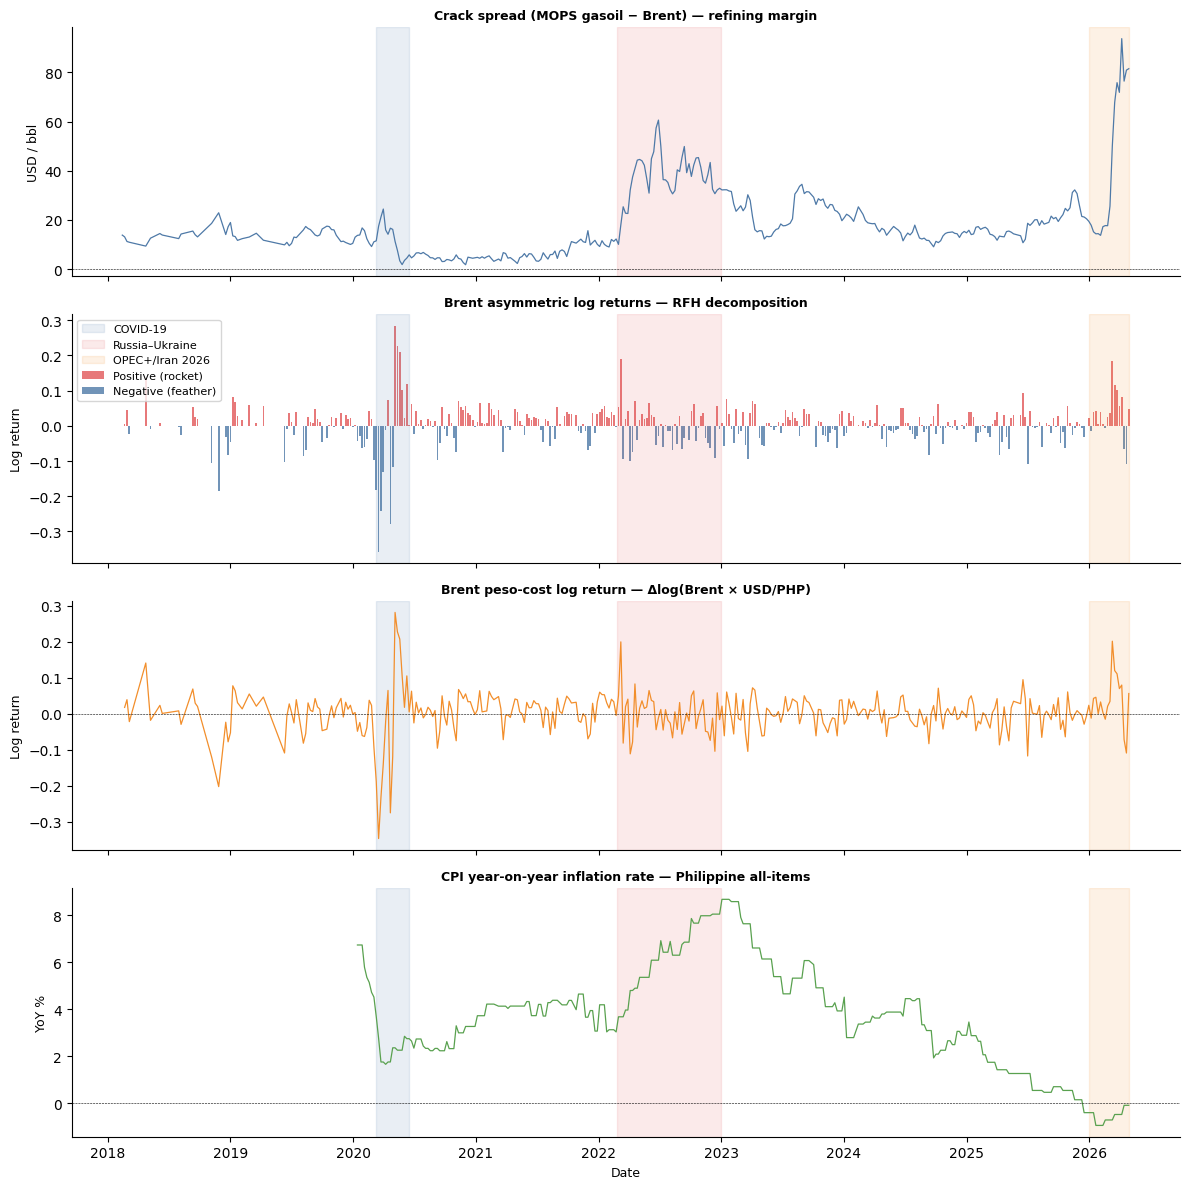

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig.subplots_adjust(hspace=0.08)

# Panel 0: Crack spread
axes[0].plot(df.index, df['crack_spread'], color='#4e79a7', linewidth=0.9)
axes[0].axhline(0, color='black', linewidth=0.4, linestyle='--')
shade_crises(axes[0])
axes[0].set_ylabel('USD / bbl', fontsize=9)
axes[0].set_title('Crack spread (MOPS gasoil − Brent) — refining margin', fontsize=9, fontweight='bold')

# Panel 1: Brent asymmetric returns
axes[1].bar(df.index, df['brent_chg_pos'], color='#e15759', width=5, alpha=0.8, label='Positive (rocket)')
axes[1].bar(df.index, df['brent_chg_neg'], color='#4e79a7', width=5, alpha=0.8, label='Negative (feather)')
shade_crises(axes[1])
axes[1].set_ylabel('Log return', fontsize=9)
axes[1].set_title('Brent asymmetric log returns — RFH decomposition', fontsize=9, fontweight='bold')
axes[1].legend(fontsize=8, loc='upper left')

# Panel 2: Brent_php log return
axes[2].plot(df.index, df['brent_php_log_ret'], color='#f28e2b', linewidth=0.9)
axes[2].axhline(0, color='black', linewidth=0.4, linestyle='--')
shade_crises(axes[2])
axes[2].set_ylabel('Log return', fontsize=9)
axes[2].set_title('Brent peso-cost log return — Δlog(Brent × USD/PHP)', fontsize=9, fontweight='bold')

# Panel 3: CPI YoY inflation
_cpi = df['cpi_yoy'].dropna()
axes[3].plot(_cpi.index, _cpi, color='#59a14f', linewidth=0.9)
axes[3].axhline(0, color='black', linewidth=0.4, linestyle='--')
shade_crises(axes[3])
axes[3].set_ylabel('YoY %', fontsize=9)
axes[3].set_xlabel('Date', fontsize=9)
axes[3].set_title('CPI year-on-year inflation rate — Philippine all-items', fontsize=9, fontweight='bold')

for ax in axes:
    fmt_xaxis(ax)

plt.tight_layout()
plt.show()


---
## Section 6 — Lag Structure

**The fundamental leakage rule**: the DOE Tuesday bulletin announces the new pump price
effective that week. Any market data from the same week (Monday–Tuesday close) is observed
*before* the bulletin is published and could in principle be used by DOE to set prices —
but since we cannot know the exact intra-week timing, all market features are lagged by
**at least one week** (shift by 1). This is a conservative, defensible choice.

The lag horizon of 1–4 weeks is motivated by the cross-correlation function between upstream
signals and diesel log returns from the EDA (Section 5), which showed significant autocorrelation
decaying after approximately four lags.

Three groups of features receive different lag treatments:

| Group | Features | Lags |
|---|---|---|
| Market drivers | Brent lags, crack spread, FX, GRP, OVX, RFH components, vol, momentum, brent_php | 1–4 |
| Own-price | `diesel_log_ret` | 1–4 |
| Regime / event | Markov prob, crisis dummies, excise impulse | 1 only |


In [15]:
# ── Define which raw features get lagged and at what depth ─────────────────

# Market driver features — lagged 1–4
# Excluded from this list:
#   brent_vol_4w/12w — subsumed by OVX in the volatility PCA block
#   dubai_log_ret    — r ≈ 0.99 with Brent; dropped in favour of the global benchmark
#   excise features  — structurally embedded in the target; no independent signal
#   ovx/vix/markov   — go to volatility PCA block (Section 10.2)
#   GPR sub-indices  — go to GPR PCA block (Section 10.3); GPR_OIL kept as direct feature
MARKET_FEATURES = [c for c in [
    'brent_log_ret',        # upstream crude rate-of-change (stationary)
    'brent_chg_pos',        # RFH positive component (unconditional)
    'brent_chg_neg',        # RFH negative component (unconditional)
    'brent_pct_1w',         # WoW % change in Brent
    'brent_php_log_ret',    # peso-cost of crude (Brent × USD/PHP)
    'crack_spread',         # refining margin (MOPS gasoil − Brent, correct sign)
    'usdphp_pct_1w',        # WoW % change in USD/PHP exchange rate
    'diesel_mom_1w',        # 1-week diesel momentum (pct_change, dimensionless)
    'diesel_mom_2w',        # 2-week diesel momentum
    'cpi_yoy',              # Philippine CPI YoY inflation (stationary)
    'GPR_OIL',              # oil-specific GPR index (direct feature; sub-indices to PCA)
] if c in df.columns]

# Own-price log return — lagged 1–4
OWN_RETURN_FEATURE = 'diesel_log_ret'

# Regime/event dummies — lag 1 only (unconditional)
REGIME_FEATURES = [c for c in [
    'd_covid',
    'd_ukraine',
    'd_iran26',
] if c in df.columns]

# Volatility PCA block base features (lagged 1–4 in Section 6 lag loop)
VOLATILITY_PCA_BASE = [c for c in [
    'ovx_mean',
    'vix_mean',
    'markov_prob_highvol',
] if c in df.columns]

# GPR PCA block base features (lagged 1–4 in Section 6 lag loop)
GPR_PCA_BASE = [c for c in [
    'GPR_AI',
    'GPR_NONOIL',
    'GPR_OIL_MiddleEast',
    'GPR_OIL_Russia',
] if c in df.columns]

print(f'Market features  (lags 1–4) : {len(MARKET_FEATURES)}')
for f in MARKET_FEATURES:
    print(f'  {f}')
print()
print(f'Own-return feature (lags 1–4): {OWN_RETURN_FEATURE}')
print()
print(f'Regime features  (lag 1 only): {REGIME_FEATURES}')
print()
print(f'Volatility PCA base          : {VOLATILITY_PCA_BASE}  → Section 10.2')
print(f'GPR PCA base                 : {GPR_PCA_BASE}  → Section 10.3')


Market features  (lags 1–4) : 11
  brent_log_ret
  brent_chg_pos
  brent_chg_neg
  brent_pct_1w
  brent_php_log_ret
  crack_spread
  usdphp_pct_1w
  diesel_mom_1w
  diesel_mom_2w
  cpi_yoy
  GPR_OIL

Own-return feature (lags 1–4): diesel_log_ret

Regime features  (lag 1 only): ['d_covid', 'd_ukraine', 'd_iran26']

Volatility PCA base          : ['ovx_mean', 'vix_mean', 'markov_prob_highvol']  → Section 10.2
GPR PCA base                 : ['GPR_AI', 'GPR_NONOIL', 'GPR_OIL_MiddleEast', 'GPR_OIL_Russia']  → Section 10.3


In [16]:
# ── Create all lag columns ─────────────────────────────────────────────────

# Market features: lags 1–4
for col in MARKET_FEATURES:
    for lag in LAGS:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# Own log return: lags 1–4
for lag in LAGS:
    df[f'{OWN_RETURN_FEATURE}_lag{lag}'] = df[OWN_RETURN_FEATURE].shift(lag)

# Regime dummies: lag 1 only
for col in REGIME_FEATURES:
    df[f'{col}_lag1'] = df[col].shift(1)

# Volatility PCA base: lags 1–4
VOL_LAG_BLOCK = []
for col in VOLATILITY_PCA_BASE:
    for lag in LAGS:
        cname = f'{col}_lag{lag}'
        df[cname] = df[col].shift(lag)
        VOL_LAG_BLOCK.append(cname)

# GPR PCA base: lags 1–4
GPR_LAG_BLOCK = []
for col in GPR_PCA_BASE:
    for lag in LAGS:
        cname = f'{col}_lag{lag}'
        df[cname] = df[col].shift(lag)
        GPR_LAG_BLOCK.append(cname)

print(f'Market lag cols        : {len(MARKET_FEATURES) * len(LAGS)}')
print(f'Own-return lag cols    : {len(LAGS)}')
print(f'Regime lag cols        : {len(REGIME_FEATURES)}')
print(f'Volatility PCA cols    : {len(VOL_LAG_BLOCK)}')
print(f'GPR PCA cols           : {len(GPR_LAG_BLOCK)}')
print(f'Total df columns       : {df.shape[1]}')

# Drop rows where the deepest lag (lag-4) is NaN — always driven by brent_log_ret_lag4
rows_before = len(df)
df = df.dropna(subset=['brent_log_ret_lag4'])
print(f'\nRows dropped (lag-4 NaN construction window) : {rows_before - len(df)}')
print(f'Remaining rows                                : {len(df)}')
print(f'Date range                                    : {df.index.min().date()}  →  {df.index.max().date()}')


Market lag cols        : 44
Own-return lag cols    : 4
Regime lag cols        : 3
Volatility PCA cols    : 12
GPR PCA cols           : 16
Total df columns       : 125

Rows dropped (lag-4 NaN construction window) : 5
Remaining rows                                : 368
Date range                                    : 2018-05-08  →  2026-04-28


---
## Section 7 — p-value Screening

Following Lunor et al. (2023, Section 2.2), each candidate feature is tested individually
against the diesel log return target using a univariate OLS regression. Features with a
two-tailed p-value below α = 0.05 are retained for the multivariate model.

**Screening applies only to candidate lag-1 market features.** Own-price lags and regime
features are included unconditionally — their relevance is established a priori by the
autocorrelation analysis (EDA Section 6) and theoretical motivation (crisis dummies).
This matches the Lunor et al. methodology of pre-screening before PCA.


In [17]:
def pvalue_screen(df, target, candidates, alpha=0.05):
    """
    Univariate OLS p-value test.

    Each candidate feature is regressed independently against the target.
    Returns a DataFrame sorted by p-value with a significance flag.

    Parameters
    ----------
    df         : DataFrame containing target and candidate columns
    target     : str, name of the target column
    candidates : list of str, candidate feature columns
    alpha      : float, significance threshold (default 0.05)

    Returns
    -------
    DataFrame with columns: feature, beta, p_value, significant
    """
    data = df[[target] + [c for c in candidates if c in df.columns]].dropna()
    y    = data[target].values
    results = []

    for feat in candidates:
        if feat not in data.columns:
            continue
        Xc     = np.column_stack([np.ones(len(data)), data[feat].values])
        beta   = np.linalg.lstsq(Xc, y, rcond=None)[0]
        resid  = y - Xc @ beta
        n, k   = Xc.shape
        s2     = (resid @ resid) / (n - k)
        se     = np.sqrt(np.diag(s2 * np.linalg.inv(Xc.T @ Xc)))
        t_stat = beta / se
        p_val  = 2 * (1 - t_dist.cdf(np.abs(t_stat[1]), df=n - k))
        results.append({
            'feature':     feat,
            'beta':        round(beta[1], 6),
            'p_value':     round(p_val, 6),
            'significant': p_val < alpha,
        })

    return pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)


# Candidate features for p-value screening: lag-1 versions of market features
# brent_chg_pos/neg are excluded from screening — they are unconditional (strong prior)
SCREEN_UNCONDITIONAL = {'brent_chg_pos_lag1', 'brent_chg_neg_lag1'}
CANDIDATES_LAG1 = [f'{c}_lag1' for c in MARKET_FEATURES
                   if f'{c}_lag1' in df.columns
                   and f'{c}_lag1' not in SCREEN_UNCONDITIONAL]

pval_df = pvalue_screen(df, 'diesel_log_ret', CANDIDATES_LAG1)
sig_feats = pval_df[pval_df['significant']]['feature'].tolist()

print(f'p-value screening  |  target: diesel_log_ret  |  α = 0.05')
print(f'Significant: {len(sig_feats)} / {len(CANDIDATES_LAG1)} candidates')
print()
print(pval_df.to_string(index=False))


p-value screening  |  target: diesel_log_ret  |  α = 0.05
Significant: 9 / 9 candidates

               feature      beta  p_value  significant
    brent_log_ret_lag1  0.371743 0.000000         True
     brent_pct_1w_lag1  0.003803 0.000000         True
brent_php_log_ret_lag1  0.373323 0.000000         True
    diesel_mom_1w_lag1  0.362273 0.000000         True
    diesel_mom_2w_lag1  0.196919 0.000000         True
          GPR_OIL_lag1  0.000027 0.001547         True
    usdphp_pct_1w_lag1  0.007541 0.042857         True
          cpi_yoy_lag1 -0.002207 0.044369         True
     crack_spread_lag1 -0.000347 0.046061         True


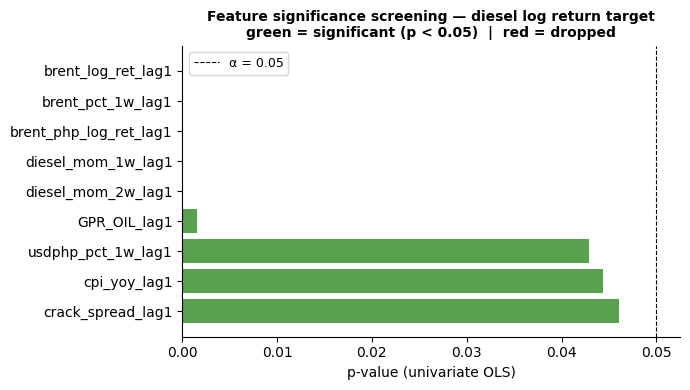

Significant features retained: ['brent_log_ret_lag1', 'brent_pct_1w_lag1', 'brent_php_log_ret_lag1', 'diesel_mom_1w_lag1', 'diesel_mom_2w_lag1', 'GPR_OIL_lag1', 'usdphp_pct_1w_lag1', 'cpi_yoy_lag1', 'crack_spread_lag1']
Dropped: []


In [18]:
# ── p-value bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, max(4, len(pval_df) * 0.42)))

colors = ['#59a14f' if s else '#e15759' for s in pval_df['significant']]
ax.barh(pval_df['feature'][::-1], pval_df['p_value'][::-1],
        color=colors[::-1], edgecolor='none')
ax.axvline(0.05, color='black', linestyle='--', linewidth=0.8, label='α = 0.05')

ax.set_xlabel('p-value (univariate OLS)', fontsize=10)
ax.set_title('Feature significance screening — diesel log return target\n'
             'green = significant (p < 0.05)  |  red = dropped', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Significant features retained: {sig_feats}')
print(f'Dropped: {pval_df[~pval_df["significant"]]["feature"].tolist()}')


---
## Section 8 — Assembling the Feature Set

The final feature set is the union of:

1. **Unconditional features** — included regardless of p-value because they have strong
   a priori theoretical justification (own-price autocorrelation, regime/crisis dummies).
2. **Significant lag-1 features** — those passing the p-value screen in Section 7.
3. **Extended lags (2–4)** for market features that were significant at lag 1 — retaining
   the full lag structure motivated by the CCF analysis.

The lag-1–4 own-price log return captures serial autocorrelation and directly
addresses the AR(1) critique (a model that only uses lag-1 price is naive;
incorporating four lags at minimum tests whether additional lag structure improves
on the AR(1) baseline).


In [19]:
# ── Unconditional features (bypass p-value screen) ────────────────────────
UNCONDITIONAL = list(dict.fromkeys([f for f in (
    # Own-price log return: lags 1–4
    [f'diesel_log_ret_lag{l}' for l in LAGS] +
    # Regime / event: lag 1 only
    [f'{c}_lag1' for c in REGIME_FEATURES] +
    # RFH asymmetric: lags 1–4 (strong prior from literature)
    [f'brent_chg_pos_lag{l}' for l in LAGS] +
    [f'brent_chg_neg_lag{l}' for l in LAGS]
) if f in df.columns]))

# ── Extend significant lag-1 features to lags 2–4 ─────────────────────────
# For each feature that passed at lag-1, include lags 2, 3, 4 as well
sig_base_features = [f.replace('_lag1', '') for f in sig_feats]
sig_extended = [f'{base}_lag{l}'
                for base in sig_base_features
                for l in LAGS
                if f'{base}_lag{l}' in df.columns]

# ── Final feature set (deduplicated) ──────────────────────────────────────
FINAL_FEATURES = list(dict.fromkeys(UNCONDITIONAL + sig_feats + sig_extended))
FINAL_FEATURES = [f for f in FINAL_FEATURES if f in df.columns]

print(f'Unconditional features       : {len(UNCONDITIONAL)}')
print(f'Significant lag-1 candidates : {len(sig_feats)}')
print(f'Sig. features extended lag2–4: {len([f for f in sig_extended if f not in set(UNCONDITIONAL+sig_feats)])}')
print(f'Final feature set (total)    : {len(FINAL_FEATURES)}')
print()
print('Final features:')
for f in FINAL_FEATURES:
    print(f'  {f}')


Unconditional features       : 15
Significant lag-1 candidates : 9
Sig. features extended lag2–4: 27
Final feature set (total)    : 51

Final features:
  diesel_log_ret_lag1
  diesel_log_ret_lag2
  diesel_log_ret_lag3
  diesel_log_ret_lag4
  d_covid_lag1
  d_ukraine_lag1
  d_iran26_lag1
  brent_chg_pos_lag1
  brent_chg_pos_lag2
  brent_chg_pos_lag3
  brent_chg_pos_lag4
  brent_chg_neg_lag1
  brent_chg_neg_lag2
  brent_chg_neg_lag3
  brent_chg_neg_lag4
  brent_log_ret_lag1
  brent_pct_1w_lag1
  brent_php_log_ret_lag1
  diesel_mom_1w_lag1
  diesel_mom_2w_lag1
  GPR_OIL_lag1
  usdphp_pct_1w_lag1
  cpi_yoy_lag1
  crack_spread_lag1
  brent_log_ret_lag2
  brent_log_ret_lag3
  brent_log_ret_lag4
  brent_pct_1w_lag2
  brent_pct_1w_lag3
  brent_pct_1w_lag4
  brent_php_log_ret_lag2
  brent_php_log_ret_lag3
  brent_php_log_ret_lag4
  diesel_mom_1w_lag2
  diesel_mom_1w_lag3
  diesel_mom_1w_lag4
  diesel_mom_2w_lag2
  diesel_mom_2w_lag3
  diesel_mom_2w_lag4
  GPR_OIL_lag2
  GPR_OIL_lag3
  GPR_OIL_l

---
## Section 9 — VIF Screening (Pre-PCA)

Variance Inflation Factors are computed on the full candidate feature set to identify
multicollinear groups. Features with VIF > 10 are candidates for PCA compression; features
with VIF < 5 can enter the model directly. This step informs the PCA block design in
Section 10.


In [20]:
X_vif    = df[FINAL_FEATURES].dropna()
vif_vals = [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]

vif_df = pd.DataFrame({
    'feature': FINAL_FEATURES,
    'VIF':     vif_vals
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF — Final feature set (pre-PCA)')
print('-' * 48)
print(vif_df.to_string(index=False))
print()
n_high = (vif_df['VIF'] > 10).sum()
print(f'Features with VIF > 10 : {n_high}  → candidates for PCA compression')
print(f'Features with VIF < 5  : {(vif_df["VIF"] < 5).sum()}  → enter model directly')


VIF — Final feature set (pre-PCA)
------------------------------------------------
               feature          VIF
    brent_log_ret_lag3          inf
    brent_chg_pos_lag3          inf
    brent_log_ret_lag2          inf
    brent_log_ret_lag1          inf
    brent_chg_neg_lag4          inf
    brent_chg_neg_lag3          inf
    brent_chg_neg_lag2          inf
    brent_chg_neg_lag1          inf
    brent_chg_pos_lag4          inf
    brent_chg_pos_lag2          inf
    brent_chg_pos_lag1          inf
    brent_log_ret_lag4          inf
brent_php_log_ret_lag1 3.197315e+06
brent_php_log_ret_lag2 3.169803e+06
brent_php_log_ret_lag3 3.129688e+06
brent_php_log_ret_lag4 3.127261e+06
    usdphp_pct_1w_lag1 4.088770e+04
    usdphp_pct_1w_lag2 4.087313e+04
    usdphp_pct_1w_lag4 4.059239e+04
    usdphp_pct_1w_lag3 4.041006e+04
    diesel_mom_1w_lag4 1.509434e+03
    diesel_mom_1w_lag3 1.397553e+03
    diesel_mom_1w_lag2 1.334446e+03
     brent_pct_1w_lag4 1.001421e+03
     brent_pct_1w

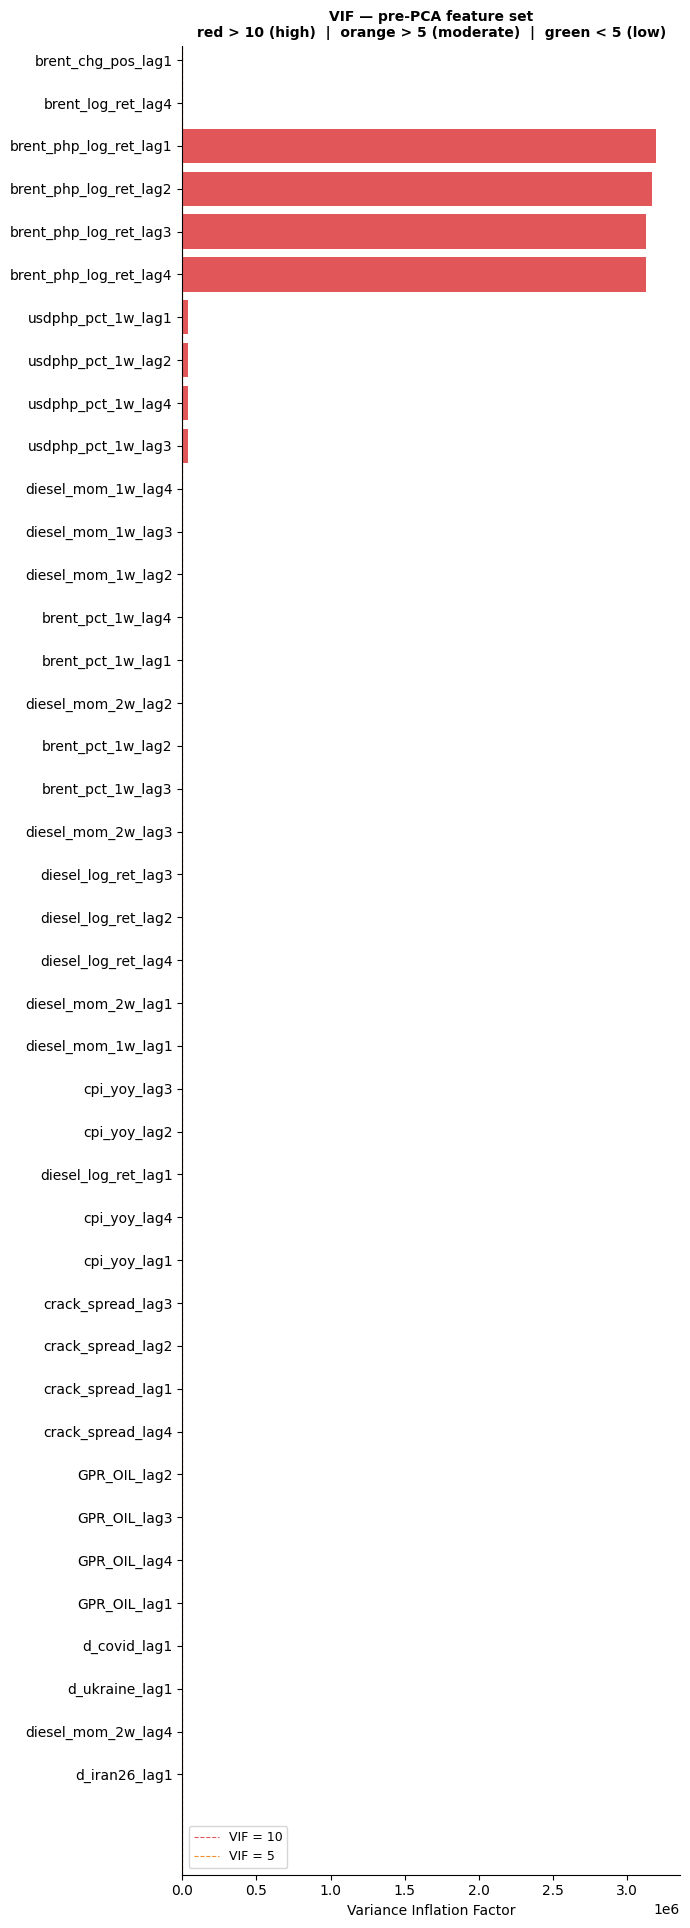

In [21]:
# ── VIF bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, max(4, len(vif_df) * 0.38)))

color_vif = ['#e15759' if v > 10 else '#f28e2b' if v > 5 else '#59a14f'
             for v in vif_df['VIF']]
ax.barh(vif_df['feature'][::-1], vif_df['VIF'][::-1],
        color=color_vif[::-1], edgecolor='none')
ax.axvline(10, color='#e15759', linestyle='--', linewidth=0.8, label='VIF = 10')
ax.axvline(5,  color='#f28e2b', linestyle='--', linewidth=0.8, label='VIF = 5')

ax.set_xlabel('Variance Inflation Factor', fontsize=10)
ax.set_title('VIF — pre-PCA feature set\n'
             'red > 10 (high)  |  orange > 5 (moderate)  |  green < 5 (low)', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## Section 10 — PCA on Collinear Feature Groups

Multiple groups of features share a common underlying driver and therefore exhibit high
collinearity across lags. Including all lags of each group directly would inflate VIFs and
destabilise linear models. Following Lunor et al. (2023, Section 2.2), PCA compresses each
group into a small number of orthogonal components that collectively explain 95% of the
group's variance.

**Three PCA blocks are constructed:**

| Block | Raw features | Rationale |
|---|---|---|
| **Crude** | `brent_log_ret`, `crack_spread`, `brent_php_log_ret` × lags 1–4 | Same upstream oil signal at different time offsets |
| **Volatility** | `ovx_mean`, `vix_mean`, `markov_prob_highvol` × lags 1–4 | Correlated fear/uncertainty measures (OVX–VIX r ≈ 0.75 from EDA) |
| **GPR** | `GPR_AI`, `GPR_NONOIL`, `GPR_OIL_MiddleEast`, `GPR_OIL_Russia` × lags 1–4 | GPR sub-indices highly correlated (r up to 0.96, EDA Section 3) |

**Critical NB04 instruction**: `StandardScaler` and `PCA` objects fitted here cover the full
available sample and are used only for diagnostics and visualisation. Inside every CV fold in
Notebook 04, a new scaler and PCA must be fitted exclusively on the training partition.
Fitting on pooled data and applying to a test fold constitutes data leakage.


In [22]:
# ── 10.1 Define PCA blocks ────────────────────────────────────────────────
# Crude block
CRUDE_PCA_BASE  = [c for c in ['brent_log_ret', 'crack_spread', 'brent_php_log_ret']
                   if c in df.columns]
crude_lag_block = [f'{c}_lag{l}' for c in CRUDE_PCA_BASE for l in LAGS
                   if f'{c}_lag{l}' in df.columns]

# Vol and GPR lag blocks were already built in Section 6
VOL_LAG_BLOCK_V = [c for c in VOL_LAG_BLOCK if c in df.columns]
GPR_LAG_BLOCK_V = [c for c in GPR_LAG_BLOCK if c in df.columns]

print(f'Crude  PCA block : {len(crude_lag_block)} columns')
print(f'Vol    PCA block : {len(VOL_LAG_BLOCK_V)} columns')
print(f'GPR    PCA block : {len(GPR_LAG_BLOCK_V)} columns')


Crude  PCA block : 12 columns
Vol    PCA block : 12 columns
GPR    PCA block : 16 columns


In [23]:
def fit_pca_block(df, block_cols, block_name, tol=0.95):
    """
    Standardise a block of lagged features and fit PCA.

    Parameters
    ----------
    df         : DataFrame (full working frame)
    block_cols : list of str, columns forming the block
    block_name : str, label used for component column names
    tol        : float, cumulative variance threshold (default 0.95)

    Returns
    -------
    dict with: pca_data, scaler, pca, X_std, evr, cum_var,
               n_components, X_transformed, W, pc_cols
    """
    pca_data = df[block_cols].dropna()
    scaler   = StandardScaler()
    X_std    = scaler.fit_transform(pca_data)
    pca_obj  = PCA()
    pca_obj.fit(X_std)
    evr     = pca_obj.explained_variance_ratio_
    cum_var = np.cumsum(evr)
    n_comp  = int(np.argmax(cum_var >= tol) + 1)
    X_pca   = pca_obj.transform(X_std)
    pc_cols = [f'{block_name}_PC{i+1}' for i in range(X_pca.shape[1])]
    X_tr    = pd.DataFrame(X_pca, columns=pc_cols, index=pca_data.index)
    W       = pd.DataFrame(pca_obj.components_,
                            index=[f'PC {i+1}' for i in range(X_pca.shape[1])],
                            columns=block_cols)

    print(f'  {block_name:<8}: {len(block_cols)} cols → {n_comp} components '
          f'at {tol*100:.0f}% variance  '
          f'(PC1 = {evr[0]*100:.1f}%,  PC2 = {evr[1]*100:.1f}%)')

    return dict(pca_data=pca_data, scaler=scaler, pca=pca_obj,
                X_std=X_std, evr=evr, cum_var=cum_var,
                n_components=n_comp, X_transformed=X_tr,
                W=W, pc_cols=pc_cols)


print('Fitting PCA blocks:')
crude_result = fit_pca_block(df, crude_lag_block,  'crude')
vol_result   = fit_pca_block(df, VOL_LAG_BLOCK_V,  'vol')
gpr_result   = fit_pca_block(df, GPR_LAG_BLOCK_V,  'gpr')

n_95_crude = crude_result['n_components']
n_95_vol   = vol_result['n_components']
n_95_gpr   = gpr_result['n_components']
print(f'\nComponents retained at 95%: crude={n_95_crude}, vol={n_95_vol}, gpr={n_95_gpr}')


Fitting PCA blocks:
  crude   : 12 cols → 5 components at 95% variance  (PC1 = 31.9%,  PC2 = 28.6%)
  vol     : 12 cols → 6 components at 95% variance  (PC1 = 60.2%,  PC2 = 18.8%)
  gpr     : 16 cols → 7 components at 95% variance  (PC1 = 54.9%,  PC2 = 19.3%)

Components retained at 95%: crude=5, vol=6, gpr=7


### 10.2 Cumulative explained variance — all three PCA blocks

Each panel uses the professor's `plot_cum_exp_var` logic applied to the three blocks.
The vertical line marks the 95% threshold; the number of components retained is annotated.


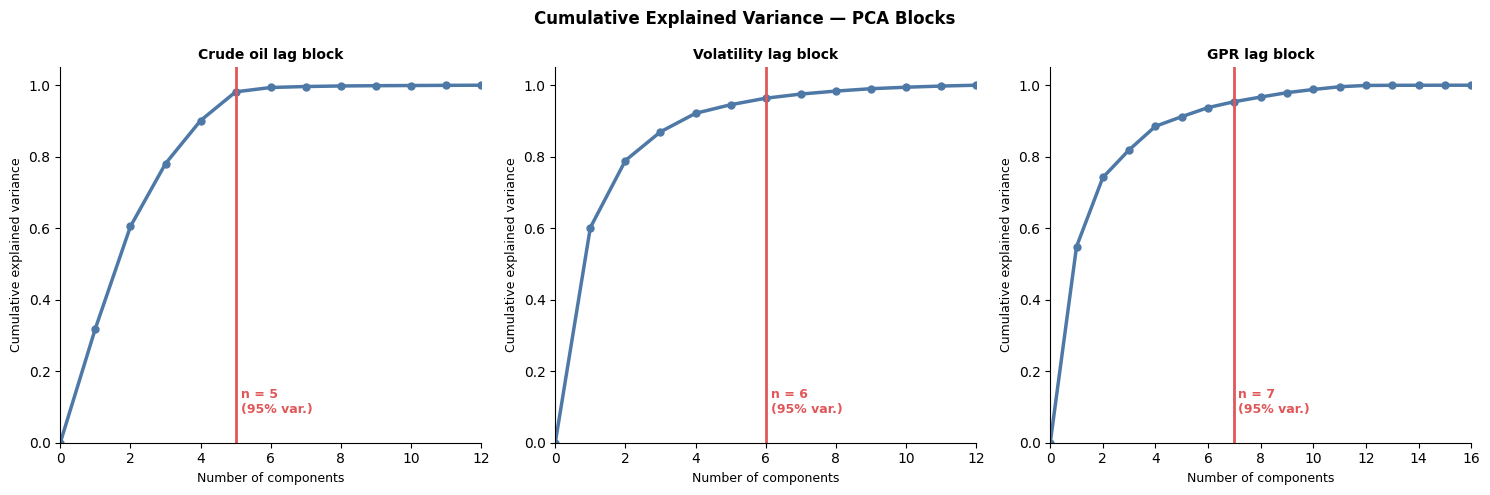

Components retained (crude=5, vol=6, gpr=7)


In [24]:
fig, axes_cv = plt.subplots(1, 3, figsize=(15, 5))

for ax, result, name in zip(
    axes_cv,
    [crude_result, vol_result, gpr_result],
    ['Crude oil lag block', 'Volatility lag block', 'GPR lag block'],
):
    evr_b = result['evr']
    cum_b = evr_b.cumsum()
    n_c   = result['n_components']

    ax.plot(range(0, len(cum_b) + 1), [0] + cum_b.tolist(),
            lw=2.5, marker='o', markersize=5, color='#4e79a7')
    ax.axvline(n_c, linestyle='-', lw=2.0, color='#e15759')

    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(n_c + 0.15, 0.08,
            f'n = {n_c}\n(95% var.)',
            color='#e15759', weight='bold', fontsize=9, transform=trans)

    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, max(len(cum_b), 4))
    ax.set_xlabel('Number of components', fontsize=9)
    ax.set_ylabel('Cumulative explained variance', fontsize=9)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Cumulative Explained Variance — PCA Blocks', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Components retained (crude={n_95_crude}, vol={n_95_vol}, gpr={n_95_gpr})')


### 10.3 PC scatter and loading biplots

For each block, the biplot shows two panels:

- **Left**: observations in PC1–PC2 space, coloured by diesel price level
- **Right**: loading vectors for each original feature (from professor's `plot_principal_components`)

Interpretation guide (from the professor's notebook):
- **Coordinates**: what direction does each PC represent?
- **Correlations**: features pointing the same way are positively correlated in latent space
- **Clusters**: groupings suggest distinct regimes
- **Funnels / Voids**: unusual spread patterns suggest regime-dependent variance


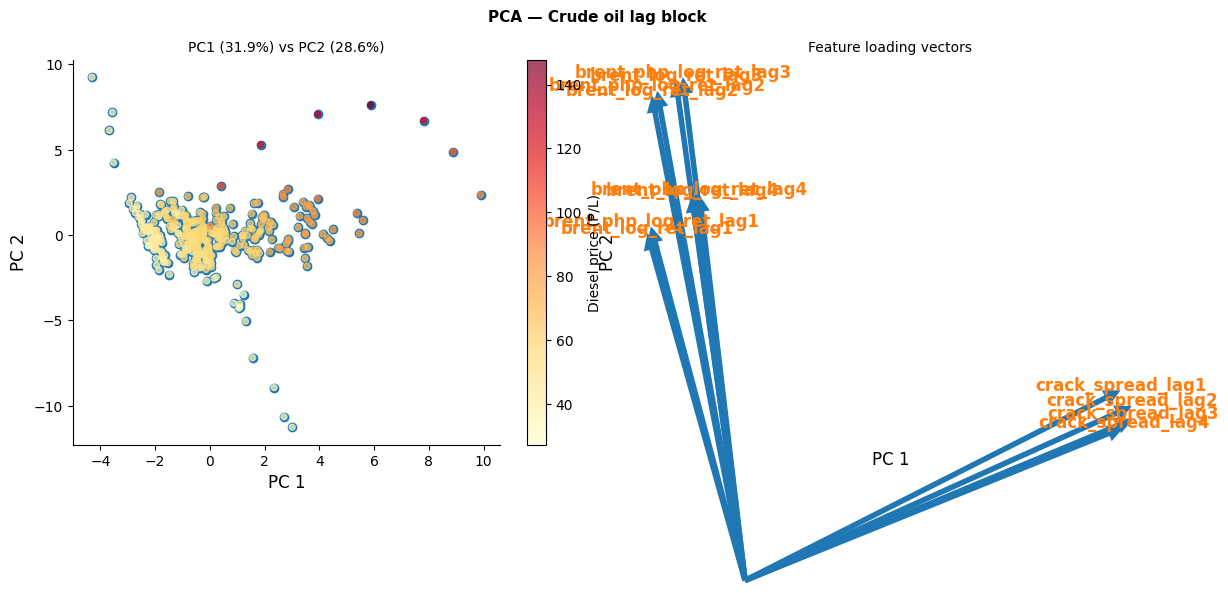

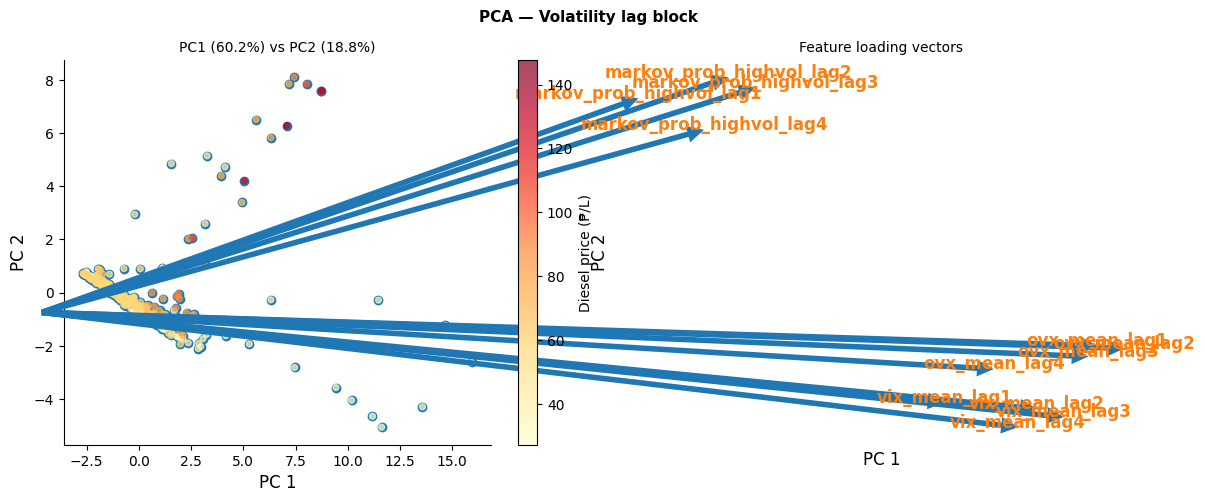

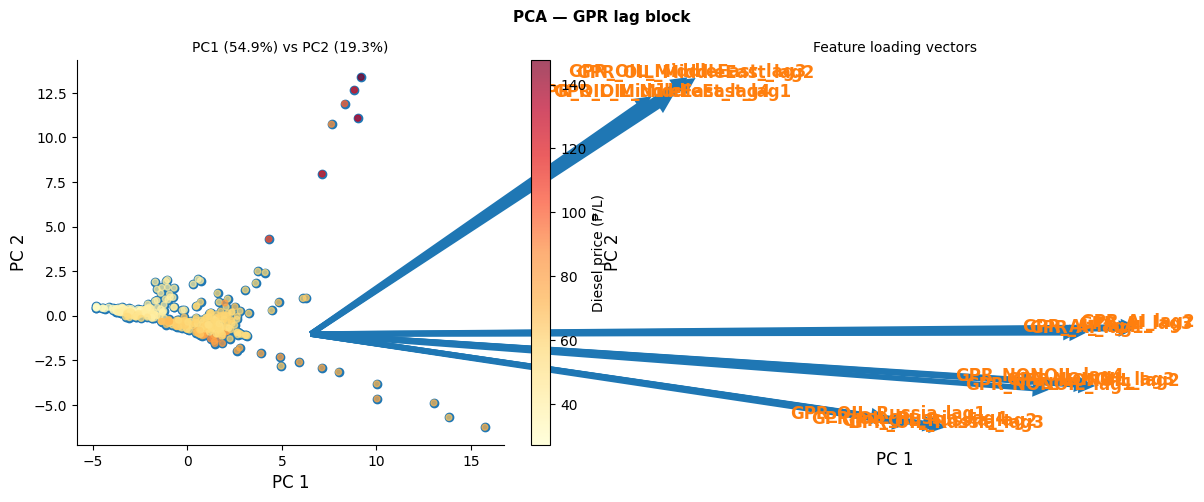

In [25]:
diesel_full = df[TARGET_PRODUCT]

for result, title in [
    (crude_result, 'Crude oil lag block'),
    (vol_result,   'Volatility lag block'),
    (gpr_result,   'GPR lag block'),
]:
    X_tr   = result['X_transformed'].copy()
    W_plot = result['W'].copy()

    # Rename to 'PC 1', 'PC 2', ... for utils.py compatibility
    pc_rename = {old: f'PC {i+1}' for i, old in enumerate(X_tr.columns)}
    X_tr   = X_tr.rename(columns=pc_rename)
    W_plot.index = [f'PC {i+1}' for i in range(len(W_plot))]

    diesel_aligned = diesel_full.reindex(X_tr.index)
    evr = result['evr']

    fig, axes = plot_principal_components(
        X_tr, W_plot,
        column_1='PC 1', column_2='PC 2',
        hue=None,
        figsize=(14, 5),
    )

    sc = axes[0].scatter(
        X_tr['PC 1'], X_tr['PC 2'],
        c=diesel_aligned, cmap='YlOrRd', s=18, alpha=0.7, zorder=10
    )
    plt.colorbar(sc, ax=axes[0], label='Diesel price (₱/L)')
    axes[0].set_title(f'PC1 ({evr[0]*100:.1f}%) vs PC2 ({evr[1]*100:.1f}%)', fontsize=10)
    axes[1].set_title('Feature loading vectors', fontsize=10)
    fig.suptitle(f'PCA — {title}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [26]:
# ── PC1 interpretation validation ─────────────────────────────────────────
print('PC1 validation — correlation with interpretable reference series')
print('-' * 62)

for result, block_name, ref_col, ref_label in [
    (crude_result, 'Crude',      'brent_mean',   'Brent USD/bbl level'),
    (vol_result,   'Volatility', 'ovx_mean',     'OVX implied vol level'),
    (gpr_result,   'GPR',        'GPR_OIL',      'GPR_OIL index level'),
]:
    X_tr = result['X_transformed']
    pc1  = X_tr.iloc[:, 0]
    if ref_col in df.columns:
        ref = df[ref_col].reindex(X_tr.index).fillna(method='ffill')
        r   = np.corrcoef(pc1, ref)[0, 1]
        print(f'  {block_name:<12} PC1 vs {ref_label:<28}: r = {r:+.4f}')
    r_d = np.corrcoef(pc1, df[TARGET_PRODUCT].reindex(X_tr.index).fillna(0))[0, 1]
    print(f'  {block_name:<12} PC1 vs diesel price level          : r = {r_d:+.4f}')
    print()

print('Expected interpretation:')
print('  Crude  PC1 : high |r| with Brent  → captures global crude price direction')
print('  Vol    PC1 : high |r| with OVX    → captures market uncertainty / fear level')
print('  GPR    PC1 : high |r| with GPR_OIL → captures geopolitical risk level')


PC1 validation — correlation with interpretable reference series
--------------------------------------------------------------
  Crude        PC1 vs Brent USD/bbl level         : r = +0.5390
  Crude        PC1 vs diesel price level          : r = +0.7349

  Volatility   PC1 vs OVX implied vol level       : r = +0.8363
  Volatility   PC1 vs diesel price level          : r = +0.0778

  GPR          PC1 vs GPR_OIL index level         : r = +0.5342
  GPR          PC1 vs diesel price level          : r = +0.7332

Expected interpretation:
  Crude  PC1 : high |r| with Brent  → captures global crude price direction
  Vol    PC1 : high |r| with OVX    → captures market uncertainty / fear level
  GPR    PC1 : high |r| with GPR_OIL → captures geopolitical risk level


---
## Section 11 — Random Forest Feature Importance Diagnostic

A Random Forest is fit on all lag-1 features against the diesel log return target. This is a
**diagnostic only** — not the final model. Its purpose is to verify that the engineered
features register non-zero importance and that no unexpected dominant feature is present.

Features with near-zero importance across all 300 trees may be candidates for removal in
Notebook 04 model selection.


In [27]:
# RF diagnostic uses lag-1 direct features only (same set that enters models directly)
# Excludes: vol/GPR PCA-block lags (those are compressed), level lags, excise
EXCL_PATTERNS = ['excise', 'diesel_lag', 'GPR_AI', 'GPR_NONOIL',
                  'GPR_OIL_Middle', 'GPR_OIL_Russia',
                  'ovx_mean_lag', 'vix_mean_lag', 'markov_prob_highvol_lag']

direct_lag1 = [c for c in df.columns
               if '_lag1' in c
               and not any(p in c for p in EXCL_PATTERNS)]

X_rf = df[direct_lag1].dropna()
y_rf = df.loc[X_rf.index, 'diesel_log_ret'].dropna()
common_idx = X_rf.index.intersection(y_rf.index)
X_rf = X_rf.loc[common_idx]
y_rf = y_rf.loc[common_idx]

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf)

imp_df = (pd.DataFrame({'feature': X_rf.columns,
                         'importance': rf.feature_importances_})
           .sort_values('importance', ascending=False)
           .head(25)
           .reset_index(drop=True))

print(f'RF diagnostic  |  {len(X_rf)} rows  |  {len(X_rf.columns)} features  |  target: diesel_log_ret')
print()
print('Top 25 features by mean decrease in impurity:')
print(imp_df.to_string(index=False))


RF diagnostic  |  320 rows  |  15 features  |  target: diesel_log_ret

Top 25 features by mean decrease in impurity:
               feature  importance
          GPR_OIL_lag1    0.208660
     crack_spread_lag1    0.180084
brent_php_log_ret_lag1    0.135910
          cpi_yoy_lag1    0.116707
    diesel_mom_1w_lag1    0.058668
    diesel_mom_2w_lag1    0.052374
    brent_log_ret_lag1    0.052042
   diesel_log_ret_lag1    0.051192
     brent_pct_1w_lag1    0.049651
    brent_chg_pos_lag1    0.043148
    usdphp_pct_1w_lag1    0.034280
    brent_chg_neg_lag1    0.011522
         d_iran26_lag1    0.002904
        d_ukraine_lag1    0.001498
          d_covid_lag1    0.001361


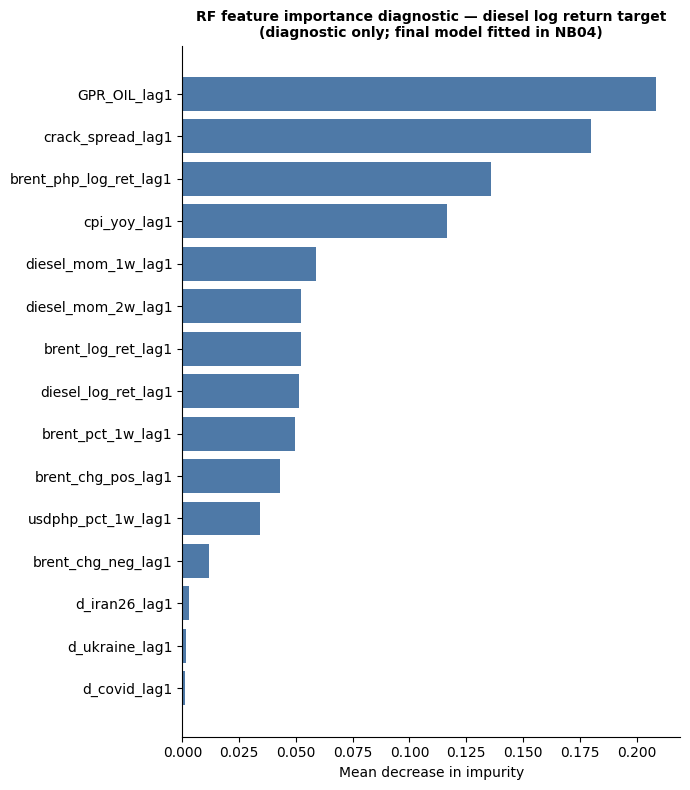

In [28]:
fig, ax = plt.subplots(figsize=(7, 8))

ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color='#4e79a7', edgecolor='none')
ax.set_xlabel('Mean decrease in impurity', fontsize=10)
ax.set_title('RF feature importance diagnostic — diesel log return target\n'
             '(diagnostic only; final model fitted in NB04)', fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## Section 12 — Save Master Frame and Feature Configuration

Two files are saved:

1. **`features_engineered.parquet`** — the full enriched DataFrame including the target
   (`diesel_log_ret`), the anchor level (`diesel`), all lagged features, and the crude lag
   block for PCA re-fitting inside CV folds.
2. **`feature_sets.json`** — a machine-readable specification listing the direct feature
   names, the crude PCA block columns, the number of PCA components to retain, and the
   back-transformation formula. Notebook 04 reads this file to reconstruct the feature
   matrix without re-running the engineering code.

> **Warning for NB04**: the `StandardScaler` and `PCA` fitted here are on the full
> available sample and must **not** be used to transform test data. They are saved to
> `pca_config.json` for reference only. Inside every CV fold, fit a new scaler and PCA on
> the training partition exclusively.


In [29]:
# ── Columns to save ────────────────────────────────────────────────────────
ALL_PCA_BLOCKS = list(dict.fromkeys(crude_lag_block + VOL_LAG_BLOCK_V + GPR_LAG_BLOCK_V))

COLS_TO_SAVE = list(dict.fromkeys(
    [TARGET_PRODUCT, 'diesel_log_ret']   # target + back-transform anchor
    + FINAL_FEATURES                      # direct feature matrix (lagged, leakage-free)
    + ALL_PCA_BLOCKS                      # raw lag blocks for re-PCA inside CV folds
))
COLS_TO_SAVE = [c for c in COLS_TO_SAVE if c in df.columns]

df_save = df[COLS_TO_SAVE].copy()

print(f'Saving {len(COLS_TO_SAVE)} columns (from {df.shape[1]} total):')
print()
for c in COLS_TO_SAVE:
    print(f'  {c:<45}  nulls: {df_save[c].isna().sum()}')


Saving 81 columns (from 125 total):

  diesel                                         nulls: 0
  diesel_log_ret                                 nulls: 0
  diesel_log_ret_lag1                            nulls: 0
  diesel_log_ret_lag2                            nulls: 0
  diesel_log_ret_lag3                            nulls: 0
  diesel_log_ret_lag4                            nulls: 0
  d_covid_lag1                                   nulls: 0
  d_ukraine_lag1                                 nulls: 0
  d_iran26_lag1                                  nulls: 0
  brent_chg_pos_lag1                             nulls: 0
  brent_chg_pos_lag2                             nulls: 0
  brent_chg_pos_lag3                             nulls: 0
  brent_chg_pos_lag4                             nulls: 0
  brent_chg_neg_lag1                             nulls: 0
  brent_chg_neg_lag2                             nulls: 0
  brent_chg_neg_lag3                             nulls: 0
  brent_chg_neg_lag4               

In [30]:
# ── Write parquet ──────────────────────────────────────────────────────────
df_save.to_parquet('data/final/features_engineered.parquet')
print(f'Saved: features_engineered.parquet  —  shape {df_save.shape}')
print(f'Rows  : {len(df_save)}')
print(f'Dates : {df_save.index.min().date()}  →  {df_save.index.max().date()}')


Saved: features_engineered.parquet  —  shape (368, 81)
Rows  : 368
Dates : 2018-05-08  →  2026-04-28


In [31]:
# ── Write feature configuration JSON ──────────────────────────────────────
feature_config = {
    'diesel': {
        'target':              'diesel_log_ret',
        'level_anchor':        TARGET_PRODUCT,
        'direct_features':     FINAL_FEATURES,
        'crude_pca_block':     crude_lag_block,
        'vol_pca_block':       VOL_LAG_BLOCK_V,
        'gpr_pca_block':       GPR_LAG_BLOCK_V,
        'n_crude_components':  int(n_95_crude),
        'n_vol_components':    int(n_95_vol),
        'n_gpr_components':    int(n_95_gpr),
        'back_transform':      'price_t = price_{t-1} * exp(log_ret_hat)',
        'notes': (
            'All direct_features are already lagged and leakage-free. '
            'Three PCA blocks (crude, vol, gpr) must each be re-fitted on training data '
            'inside every CV fold in NB04. '
            'Never apply full-sample scaler/PCA to test data. '
            'Excluded: excise tax (in target), dubai (r≈0.99 Brent), '
            'brent_vol_4w/12w (subsumed by OVX in vol PCA).'
        ),
    }
}

with open('data/final/feature_sets.json', 'w') as fh:
    json.dump(feature_config, fh, indent=2)
print('Saved: feature_sets.json')

pca_config = {
    'crude_pca_block':     crude_lag_block,
    'vol_pca_block':       VOL_LAG_BLOCK_V,
    'gpr_pca_block':       GPR_LAG_BLOCK_V,
    'n_crude_95pct':       int(n_95_crude),
    'n_vol_95pct':         int(n_95_vol),
    'n_gpr_95pct':         int(n_95_gpr),
    'warning': (
        'Diagnostic reference only. '
        'Re-fit StandardScaler + PCA on training data inside each CV fold in NB04.'
    ),
}
with open('data/final/pca_config.json', 'w') as fh:
    json.dump(pca_config, fh, indent=2)
print('Saved: pca_config.json')


Saved: feature_sets.json
Saved: pca_config.json


In [32]:
# ── Final sanity check ────────────────────────────────────────────────────
df_check = pd.read_parquet('data/final/features_engineered.parquet')

print('=' * 62)
print('FEATURE ENGINEERING — FINAL SANITY CHECK')
print('=' * 62)
print(f'Shape             : {df_check.shape}')
print(f'Date range        : {df_check.index.min().date()}  →  {df_check.index.max().date()}')
print(f'Total nulls       : {df_check.isna().sum().sum()}')
print()
print('Null counts by column (non-zero only):')
null_nz = df_check.isna().sum()
null_nz = null_nz[null_nz > 0]
if len(null_nz) == 0:
    print('  None — feature matrix is complete.')
else:
    print(null_nz.to_string())
print()
print('Target statistics:')
print(df_check['diesel_log_ret'].describe().round(6).to_string())
print()
print('Back-transform check:')
p_prev     = df_check['diesel'].shift(1)
pred_level = p_prev * np.exp(df_check['diesel_log_ret'])
err        = (pred_level - df_check['diesel']).abs().dropna()
print(f'  Max reconstruction error : {err.max():.2e}  (expected: near machine epsilon)')
print()
print('Decision log:')
print(f'  Target             : diesel_log_ret  (ADF p < 0.01 after differencing)')
print(f'  Excise tax         : fully excluded  (structurally embedded in target)')
print(f'  Dubai crude        : excluded  (r ≈ 0.99 with Brent; no marginal info)')
print(f'  Brent vol 4w/12w   : excluded  (subsumed by OVX in volatility PCA block)')
print(f'  CPI                : cpi_yoy = pct_change(52) × 100  (YoY inflation, stationary)')
print(f'  Momentum units     : pct_change (dimensionless, consistent with log-return target)')
print(f'  Crack spread sign  : MOPS_gasoil − Brent (positive = profitable refining margin)')
print(f'  Lag structure      : market lags 1–4  |  own-return lags 1–4  |  regime lag 1')
print(f'  p-value screen     : {len(sig_feats)} significant from {len(CANDIDATES_LAG1)} candidates (α = 0.05)')
print(f'  PCA crude          : {len(crude_lag_block)} cols → {n_95_crude} components at 95%')
print(f'  PCA volatility     : {len(VOL_LAG_BLOCK_V)} cols → {n_95_vol} components at 95%')
print(f'  PCA GPR            : {len(GPR_LAG_BLOCK_V)} cols → {n_95_gpr} components at 95%')
print(f'  RFH asymmetry      : brent_chg_pos, brent_chg_neg (unconditional, lags 1–4)')
print(f'  Crisis dummies     : d_covid, d_ukraine, d_iran26 (lag 1, unconditional)')
print(f'  brent_php_log_ret  : included (Brent × USD/PHP — peso cost of crude)')
print(f'  bfill              : never used')
print()
print('NB04 instructions:')
print('  1. Load features_engineered.parquet and feature_sets.json')
print('  2. Inside each CV fold on the TRAINING partition ONLY:')
print('       a. Fit StandardScaler + PCA for crude_pca_block')
print('       b. Fit StandardScaler + PCA for vol_pca_block')
print('       c. Fit StandardScaler + PCA for gpr_pca_block')
print('       d. Transform both train and test with fold-specific scaler+PCA objects')
print('  3. Final model input = direct_features + crude_PCs + vol_PCs + gpr_PCs')
print('  4. Predict diesel_log_ret; back-transform: price_t = price_{t-1} * exp(pred)')
print('  5. Report MAPE and RMSE in ₱/L after back-transformation')
print('  6. Report directional accuracy (sign(Δprice)) as a separate metric')


FEATURE ENGINEERING — FINAL SANITY CHECK
Shape             : (368, 81)
Date range        : 2018-05-08  →  2026-04-28
Total nulls       : 199

Null counts by column (non-zero only):
cpi_yoy_lag1          48
diesel_mom_2w_lag4     1
cpi_yoy_lag2          49
cpi_yoy_lag3          50
cpi_yoy_lag4          51

Target statistics:
count    368.000000
mean       0.001905
std        0.042646
min       -0.224966
25%       -0.014623
50%        0.000379
75%        0.016802
max        0.334706

Back-transform check:
  Max reconstruction error : 1.42e-14  (expected: near machine epsilon)

Decision log:
  Target             : diesel_log_ret  (ADF p < 0.01 after differencing)
  Excise tax         : fully excluded  (structurally embedded in target)
  Dubai crude        : excluded  (r ≈ 0.99 with Brent; no marginal info)
  Brent vol 4w/12w   : excluded  (subsumed by OVX in volatility PCA block)
  CPI                : cpi_yoy = pct_change(52) × 100  (YoY inflation, stationary)
  Momentum units     : pct_